In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [2]:
cancer = load_breast_cancer()
x = cancer['data']
# print(X.shape)

#Column Standarise
mu = x.mean(axis=0)
std = x.std(axis=0)
X_ = (x-mu)/std

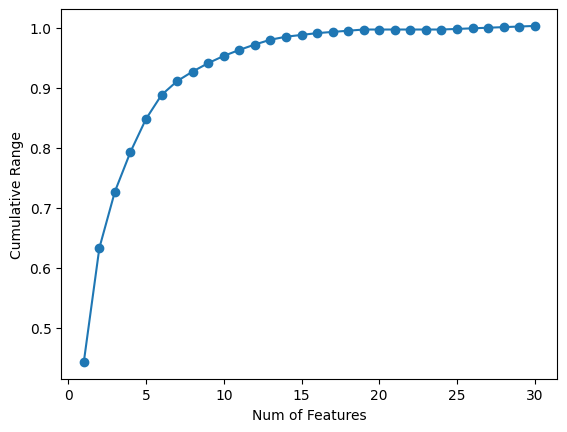

In [3]:
#Square Matrix
SqrMatrix = np.dot(X_.T,X_)

#Compute eigenvectors and eigenvalues
lambdas , vectors = np.linalg.eig(SqrMatrix)
top_5 = lambdas[:3]

#Obtain v1 to v3 eigen values
V = vectors[ : , 0:3]

#Projection
proj = np.dot(X_,V)

#Cumulative
total = sum(lambdas)
covariance = lambdas/total
covariance = np.round(covariance,3)
cumulative = np.cumsum(covariance)

#Graph the Cumulative Curve
plt.plot(range(1, len(cumulative)+1) ,cumulative, marker="o")
plt.xlabel("Num of Features")
plt.ylabel("Cumulative Range")
plt.show()

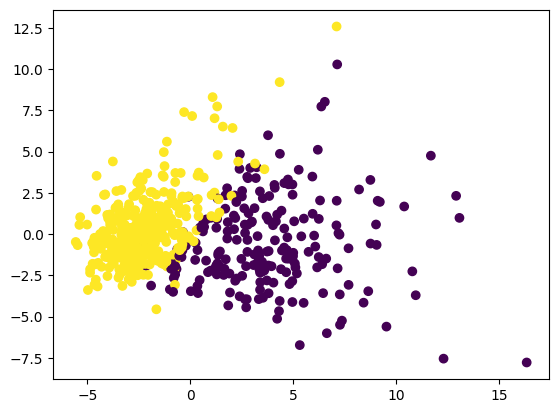

In [5]:
#Data
X = proj
y = cancer['target']
n_features = X.shape[1]

#Visualise the Data Set
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")
plt.show()

In [6]:
#Training Split
XT , Xt , yT , yt = train_test_split(X , y, test_size=0.25, random_state=0, shuffle=False)
yT = yT.reshape(-1,1)
yt = yt.reshape(-1,1)

In [7]:
#Modelling
def AddBias(X):
    m = X.shape[0]
    if np.all(X[:, 0] == 1):
        return X
    else:
        ones = np.ones((m, 1))
        X = np.hstack((ones, X))
    return X

XT = AddBias(XT)
Xt = AddBias(Xt)

def Sigmoid(z):
    return 1/(1+np.exp(-z))

def Hypothesis(X,theta):
    return Sigmoid(np.dot(X,theta))

def LossFunction(y,yp):
    epsilon = 1e-8
    loss = -np.mean(y * np.log(yp + epsilon) + (1-y) * np.log(1 - yp + epsilon))
    return loss

def GradientComputation(X,y,yp):
    m = X.shape[0]
    inside_func = np.dot(X.T,(y-yp))
    return -inside_func/m

def Train(X,y,learning_rate=0.1,max_iters=500):
    error_list = []
    theta = np.random.randn(X.shape[1],1)
    for i in range(max_iters):
        yp = Hypothesis(X, theta)
        grad = GradientComputation(X,y,yp)
        e = LossFunction(y,yp)
        error_list.append(e)
        theta = theta - learning_rate*grad
    plt.plot(error_list)
    plt.show()
    return theta

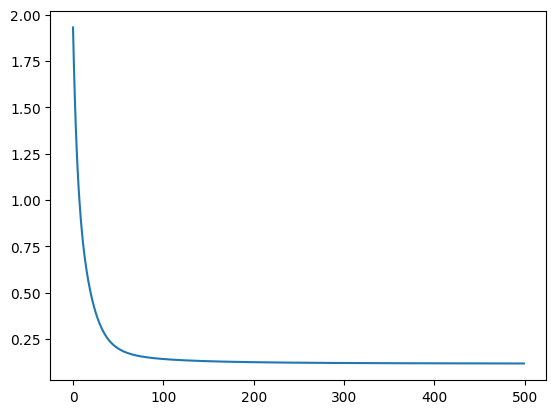

In [8]:
def Predictions(X, theta):
    yp = Hypothesis(X, theta)
    yp = yp.flatten()
    preds = np.zeros_like(yp, dtype=int)
    preds[yp > 0.5] = 1
    return preds

def Accuracy(X, y, theta):
    preds = Predictions(X, theta)
    return ((y.flatten() == preds).sum() / y.shape[0]) * 100

theta = Train(XT,yT)

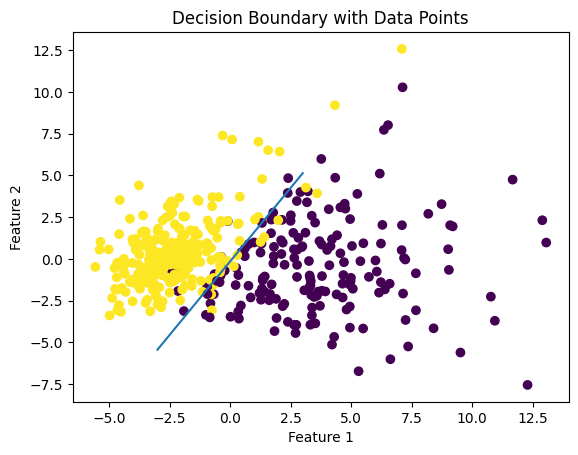

94.36619718309859
96.5034965034965


In [9]:
#Boundary Line
theta_flat = theta.flatten()
x1 = np.linspace(-3, 3, 100)
x2 = -(theta_flat[0] + theta_flat[1] * x1) / theta_flat[2]
plt.scatter(XT[:,1], XT[:,2], c=yT, cmap="viridis")
plt.plot(x1, x2)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary with Data Points")
plt.show()

print(Accuracy(XT,yT,theta))
print(Accuracy(Xt,yt,theta))